# Individual spectrum checks

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from astropy.table import Table
from astropy.io import fits
from sdss_access import Access
access = Access(release='dr19')

import paths
from utils import vac2air

plt.style.use(paths.styles / 'notebook.mplstyle')

In [3]:
mwm_sample = pd.read_csv(paths.data / 'MWM' / 'sample.csv', index_col='sdss_id')
mwm_sample

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,27021597851161007,...,8.590056,0.0,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003,True,False
54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,27021597851161095,...,9.153462,0.0,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048,True,False
54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,27021597851160855,...,10.254416,0.0,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869,True,False
54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,27021597851164071,...,9.035937,0.0,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037,True,False
54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,27021597851163901,...,14.852359,0.0,-0.182748,0.012715,0.005658,-0.005658,0.201122,0.195464,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,27021599359029628,...,7.758100,0.0,-0.059793,0.246831,0.047802,-0.047802,0.354426,0.306624,True,False
129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,27021599365533938,...,10.770966,0.0,-0.523929,-0.496442,-0.060767,0.060767,-0.033280,0.027487,True,False
129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,27021599358122770,...,4.912325,0.0,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831,True,False


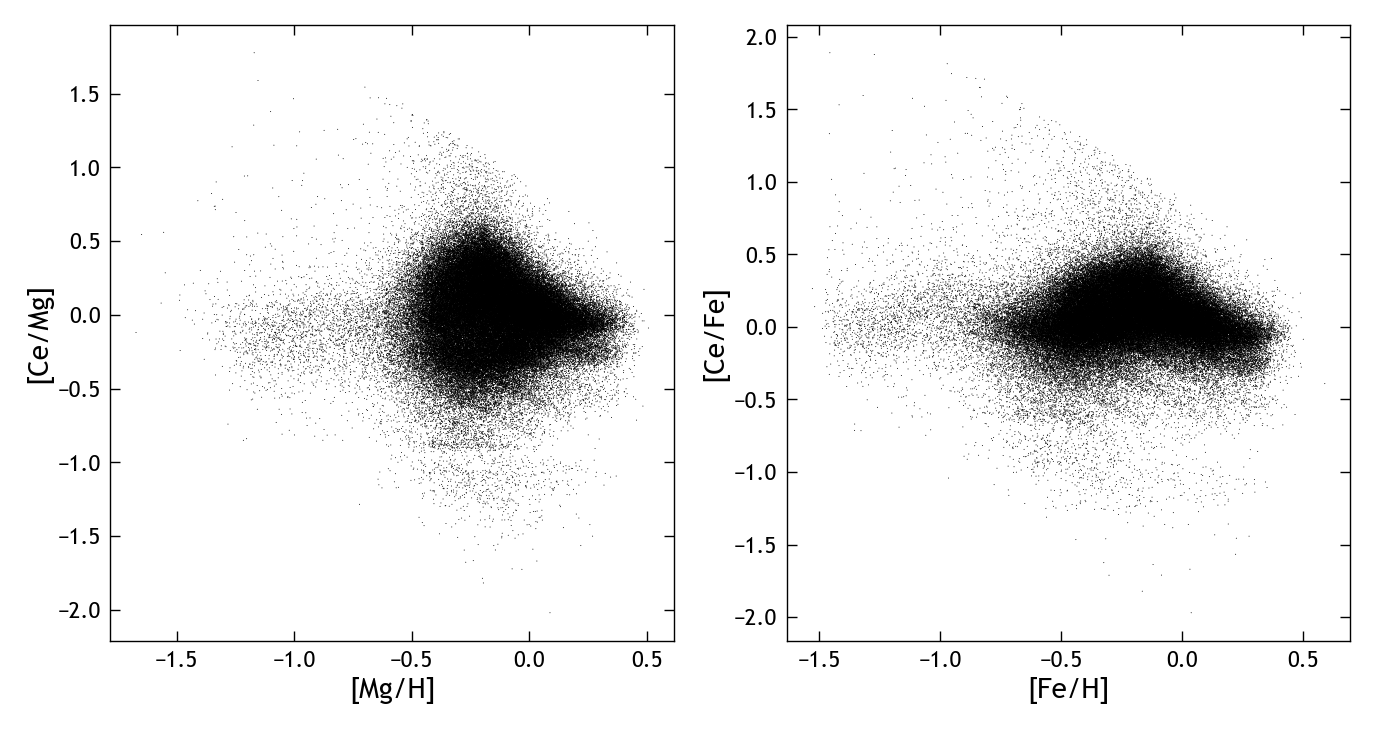

In [91]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(
    mwm_sample['mg_h'], mwm_sample['ce_mg'],
    s=0.5, marker='.', rasterized=True, edgecolor='none', c='k'
)
axs[0].set_xlabel('[Mg/H]')
axs[0].set_ylabel('[Ce/Mg]')
axs[1].scatter(
    mwm_sample['fe_h'], mwm_sample['ce_fe'],
    s=0.5, marker='.', rasterized=True, edgecolor='none', c='k'
)
axs[1].set_xlabel('[Fe/H]')
axs[1].set_ylabel('[Ce/Fe]')
plt.show()

In [4]:
all_mwm = Table.read(paths.data / 'MWM' / 'astraAllStarASPCAP-0.6.0.fits.gz', hdu=2)

## Get a test spectrum

In [5]:
# Find star in Cunha+ (2017)
all_mwm[all_mwm['obj'] == '2M15203732-0207263']

sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,catalogid31,n_associated,n_neighborhood,sdss5_target_flags,sdss4_apogee_target1_flags,sdss4_apogee_target2_flags,sdss4_apogee2_target1_flags,sdss4_apogee2_target2_flags,sdss4_apogee2_target3_flags,sdss4_apogee_member_flags,sdss4_apogee_extra_target_flags,ra,dec,l,b,plx,e_plx,pmra,e_pmra,pmde,e_pmde,gaia_v_rad,gaia_e_v_rad,g_mag,bp_mag,rp_mag,j_mag,e_j_mag,h_mag,e_h_mag,k_mag,e_k_mag,ph_qual,bl_flg,cc_flg,w1_mag,e_w1_mag,w1_flux,w1_dflux,w1_frac,w2_mag,e_w2_mag,w2_flux,w2_dflux,w2_frac,w1uflags,w2uflags,w1aflags,w2aflags,mag4_5,d4_5m,rms_f4_5,sqf_4_5,mf4_5,csf,zgr_teff,zgr_e_teff,zgr_logg,zgr_e_logg,zgr_fe_h,zgr_e_fe_h,zgr_e,zgr_e_e,zgr_plx,zgr_e_plx,zgr_teff_confidence,zgr_logg_confidence,zgr_fe_h_confidence,zgr_ln_prior,zgr_chi2,zgr_quality_flags,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,bailer_jones_flags,ebv,e_ebv,ebv_flags,ebv_zhang_2023,e_ebv_zhang_2023,ebv_sfd,e_ebv_sfd,ebv_rjce_glimpse,e_ebv_rjce_glimpse,ebv_rjce_allwise,e_ebv_rjce_allwise,ebv_bayestar_2019,e_ebv_bayestar_2019,ebv_edenhofer_2023,e_ebv_edenhofer_2023,c_star,u_jkc_mag,u_jkc_mag_flag,b_jkc_mag,b_jkc_mag_flag,v_jkc_mag,v_jkc_mag_flag,r_jkc_mag,r_jkc_mag_flag,i_jkc_mag,i_jkc_mag_flag,u_sdss_mag,u_sdss_mag_flag,g_sdss_mag,g_sdss_mag_flag,r_sdss_mag,r_sdss_mag_flag,i_sdss_mag,i_sdss_mag_flag,z_sdss_mag,z_sdss_mag_flag,y_ps1_mag,y_ps1_mag_flag,n_boss_visits,boss_min_mjd,boss_max_mjd,n_apogee_visits,apogee_min_mjd,apogee_max_mjd,source,star_pk,spectrum_pk,release,filetype,apred,apstar,obj,telescope,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,task_pk,source_pk,v_astra,created,t_elapsed,t_overhead,tag,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,flag_warn,flag_bad,stellar_parameters_task_pk,al_h_task_pk,c_12_13_task_pk,ca_h_task_pk,ce_h_task_pk,c_1_h_task_pk,c_h_task_pk,co_h_task_pk,cr_h_task_pk,cu_h_task_pk,fe_h_task_pk,k_h_task_pk,mg_h_task_pk,mn_h_task_pk,na_h_task_pk,nd_h_task_pk,ni_h_task_pk,n_h_task_pk,o_h_task_pk,p_h_task_pk,si_h_task_pk,s_h_task_pk,ti_h_task_pk,ti_2_h_task_pk,v_h_task_pk,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn

In [6]:
all_mwm[all_mwm['obj'] == '2M19411367+4003382']

sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,catalogid31,n_associated,n_neighborhood,sdss5_target_flags,sdss4_apogee_target1_flags,sdss4_apogee_target2_flags,sdss4_apogee2_target1_flags,sdss4_apogee2_target2_flags,sdss4_apogee2_target3_flags,sdss4_apogee_member_flags,sdss4_apogee_extra_target_flags,ra,dec,l,b,plx,e_plx,pmra,e_pmra,pmde,e_pmde,gaia_v_rad,gaia_e_v_rad,g_mag,bp_mag,rp_mag,j_mag,e_j_mag,h_mag,e_h_mag,k_mag,e_k_mag,ph_qual,bl_flg,cc_flg,w1_mag,e_w1_mag,w1_flux,w1_dflux,w1_frac,w2_mag,e_w2_mag,w2_flux,w2_dflux,w2_frac,w1uflags,w2uflags,w1aflags,w2aflags,mag4_5,d4_5m,rms_f4_5,sqf_4_5,mf4_5,csf,zgr_teff,zgr_e_teff,zgr_logg,zgr_e_logg,zgr_fe_h,zgr_e_fe_h,zgr_e,zgr_e_e,zgr_plx,zgr_e_plx,zgr_teff_confidence,zgr_logg_confidence,zgr_fe_h_confidence,zgr_ln_prior,zgr_chi2,zgr_quality_flags,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,bailer_jones_flags,ebv,e_ebv,ebv_flags,ebv_zhang_2023,e_ebv_zhang_2023,ebv_sfd,e_ebv_sfd,ebv_rjce_glimpse,e_ebv_rjce_glimpse,ebv_rjce_allwise,e_ebv_rjce_allwise,ebv_bayestar_2019,e_ebv_bayestar_2019,ebv_edenhofer_2023,e_ebv_edenhofer_2023,c_star,u_jkc_mag,u_jkc_mag_flag,b_jkc_mag,b_jkc_mag_flag,v_jkc_mag,v_jkc_mag_flag,r_jkc_mag,r_jkc_mag_flag,i_jkc_mag,i_jkc_mag_flag,u_sdss_mag,u_sdss_mag_flag,g_sdss_mag,g_sdss_mag_flag,r_sdss_mag,r_sdss_mag_flag,i_sdss_mag,i_sdss_mag_flag,z_sdss_mag,z_sdss_mag_flag,y_ps1_mag,y_ps1_mag_flag,n_boss_visits,boss_min_mjd,boss_max_mjd,n_apogee_visits,apogee_min_mjd,apogee_max_mjd,source,star_pk,spectrum_pk,release,filetype,apred,apstar,obj,telescope,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,task_pk,source_pk,v_astra,created,t_elapsed,t_overhead,tag,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,flag_warn,flag_bad,stellar_parameters_task_pk,al_h_task_pk,c_12_13_task_pk,ca_h_task_pk,ce_h_task_pk,c_1_h_task_pk,c_h_task_pk,co_h_task_pk,cr_h_task_pk,cu_h_task_pk,fe_h_task_pk,k_h_task_pk,mg_h_task_pk,mn_h_task_pk,na_h_task_pk,nd_h_task_pk,ni_h_task_pk,n_h_task_pk,o_h_task_pk,p_h_task_pk,si_h_task_pk,s_h_task_pk,ti_h_task_pk,ti_2_h_task_pk,v_h_task_pk,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn

In [10]:
test_id = 88883116
access.remote()
access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=test_id)
access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=test_id)
access.set_stream()
access.commit()

Progress:  50%|█████     | 1/2 [00:05<00:05,  5.01s/files, n_files=2, n_streams=2]

SDSS_ACCESS> Done!


In [11]:
mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=test_id)
print(mwmStar_filename)
access.exists('', full=mwmStar_filename)

astraStar_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=test_id)
print(astraStar_filename)
access.exists('', full=astraStar_filename)

/Users/liam/sas/dr19/spectro/astra/0.6.0/spectra/star/31/16/mwmStar-0.6.0-88883116.fits
/Users/liam/sas/dr19/spectro/astra/0.6.0/results/star/31/16/astraStarASPCAP-0.6.0-88883116.fits


True

In [12]:
with fits.open(mwmStar_filename) as hdul:
    print(hdul.info())

Filename: /Users/liam/sas/dr19/spectro/astra/0.6.0/spectra/star/31/16/mwmStar-0.6.0-88883116.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     113   ()      
  1  BOSS/APO      1 BinTableHDU    131   0R x 35C   [K, 1A, 1A, 1A, J, K, 1A, 1A, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, K, K, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
  2  BOSS/LCO      1 BinTableHDU    131   0R x 35C   [K, 1A, 1A, 1A, J, K, 1A, 1A, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, K, K, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
  3  APOGEE/APO    1 BinTableHDU    157   1R x 45C   [K, 5A, 6A, 5A, J, K, 3A, 18A, 6A, J, J, J, J, J, J, E, E, E, K, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, E, E, J, 8575E, 8575E, 8575E, 8575E, 8575E, 8575E, E, K]   
  4  APOGEE/LCO    1 BinTableHDU    157   0R x 45C   [K, 1A, 1A, 1A, J, K, 1A, 1A, 1A, J, J, J, J, J, J, E, E, E, K, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, E, E, J, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
None


In [13]:
with fits.open(astraStar_filename) as hdul:
    print(hdul.info())

Filename: /Users/liam/sas/dr19/spectro/astra/0.6.0/results/star/31/16/astraStarASPCAP-0.6.0-88883116.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     113   ()      
  1  BOSS/APO      1 BinTableHDU    735   0R x 310C   [1A, 1A, 1A, J, J, K, J, J, E, J, J, J, J, J, E, J, J, J, J, J, J, J, E, E, E, E, E, 1A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, K, K, L, E, 0E, 0E, K, K, E, E, E, E, E, E, E, E, E, K, K, 1A, 26A, E, E, 1A, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, E, K, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, 1A, J, E, J, K, E, E, E, E, K, K, K, K, K, K, K, K, K, K, K, K, K

In [44]:
mwmStar = Table.read(mwmStar_filename, hdu=3)
obs_wl = mwmStar['wavelength'][0]
obs_flux = mwmStar['flux'][0]
obs_err = mwmStar['ivar'][0]**-0.5
obs_cont = mwmStar['continuum'][0]

# Vacuum-to-air wavelength conversion
# Observed wavelengths are vacuum, whereas Ce lines are given in air
air_wl = vac2air(obs_wl)

# Correct for Doppler shift
c = 2.99792e5 # km/s
rest_wl = air_wl * (1 + mwmStar['v_rad'][0] / c)**-1
print(1 + mwmStar['v_rad'][0] / c)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_66092/3539374503.py:4: RuntimeWarning: divide by zero encountered in power
  obs_err = mwmStar['ivar'][0]**-0.5



1.0000343


In [45]:
air_wl - obs_wl

array([-4.126953, -4.126953, -4.126953, ..., -4.642578, -4.642578,
       -4.642578], shape=(8575,), dtype=float32)

In [46]:
air_wl - rest_wl

array([0.5185547, 0.5185547, 0.5185547, ..., 0.5839844, 0.5839844,
       0.5839844], shape=(8575,), dtype=float32)

In [34]:
mwmStar

spectrum_pk_id,release,filetype,v_astra,healpix,sdss_id,apred,obj,telescope,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,wavelength,flux,ivar,pixel_flags,continuum,nmf_rectified_model_flux,nmf_rchi2,nmf_flags
int64,bytes5,bytes6,bytes5,int32,int64,bytes3,bytes18,bytes6,int32,int32,int32,int32,int32,int32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64
44931839,sdss5,apStar,0.6.0,101959,88883116,1.3,2M15203732-0207263,apo25m,60094,60094,-1,1,1,1,170.35916,148.0,0.0,0,10.290866,0.0,0.0,--,3996.4841,3.3136444,2.1966736,0.017726876,-1.1869739,0.00643559,4.6380424,0,--,--,--,--,--,1,15100.802 .. 16999.807,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,-- .. --,5.613392,0


In [35]:
astraStar = Table.read(astraStar_filename, hdu=3)
model_wl = astraStar['wavelength'][-1]
model_flux = astraStar['model_flux'][-1]
model_ce_flux = astraStar['model_flux_ce_h'][-1]
model_cont = astraStar['continuum'][-1]
print(model_flux)

[-- -- -- ... -- -- --]


In [36]:
astraStar

star_pk,release,filetype,apred,apstar,obj,telescope,healpix,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,spectrum_pk_id,task_pk,v_astra,created,t_elapsed,t_overhead,tag,wavelength,model_flux,continuum,model_flux_al_h,model_flux_c_12_13,model_flux_ca_h,model_flux_ce_h,model_flux_c_1_h,model_flux_c_h,model_flux_co_h,model_flux_cr_h,model_flux_cu_h,model_flux_fe_h,model_flux_k_h,model_flux_mg_h,model_flux_mn_h,model_flux_na_h,model_flux_nd_h,model_flux_ni_h,model_flux_n_h,model_flux_o_h,model_flux_p_h,model_flux_si_h,model_flux_s_h,model_flux_ti_h,model_flux_ti_2_h,model_flux_v_h,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,snr,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,stellar_parameters_task_pk_id,al_h_task_pk_id,c_12_13_task_pk_id,ca_h_task_pk_id,ce_h_task_pk_id,c_1_h_task_pk_id,c_h_task_pk_id,co_h_task_pk_id,cr_h_task_pk_id,cu_h_task_pk_id,fe_h_task_pk_id,k_h_task_pk_id,mg_h_task_pk_id,mn_h_task_pk_id,na_h_task_pk_id,nd_h_task_pk_id,ni_h_task_pk_id,n_h_task_pk_id,o_h_task_pk_id,p_h_task_pk_id,si_h_task_pk_id,s_h_task_pk_id,ti_h_task_pk_id,ti_2_h_task_pk_id,v_h_task_pk_id,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn_h,raw_na_h,raw_e_na_h,raw_nd_h,raw_e_nd_h,raw_ni_h,raw_e_ni_h,raw_n_h,raw_e_n_h,raw_o_h,raw_e_o_h,raw_p_h,raw_e_p_h,raw_si_h,raw_e_si_h,raw_s_h,raw_e_s_h,raw_ti_h,raw_e_ti_h,raw_ti_2_h,raw_e_ti_2_h,raw_v_h,raw_e_v_h
int64,bytes5,bytes6,bytes3,bytes5,bytes18,bytes6,int32,bytes1,bytes1,int32,int32,int32,int32,int32,int32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,int64,int64,bytes5,bytes26,float32,float32,bytes1,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,int64,float

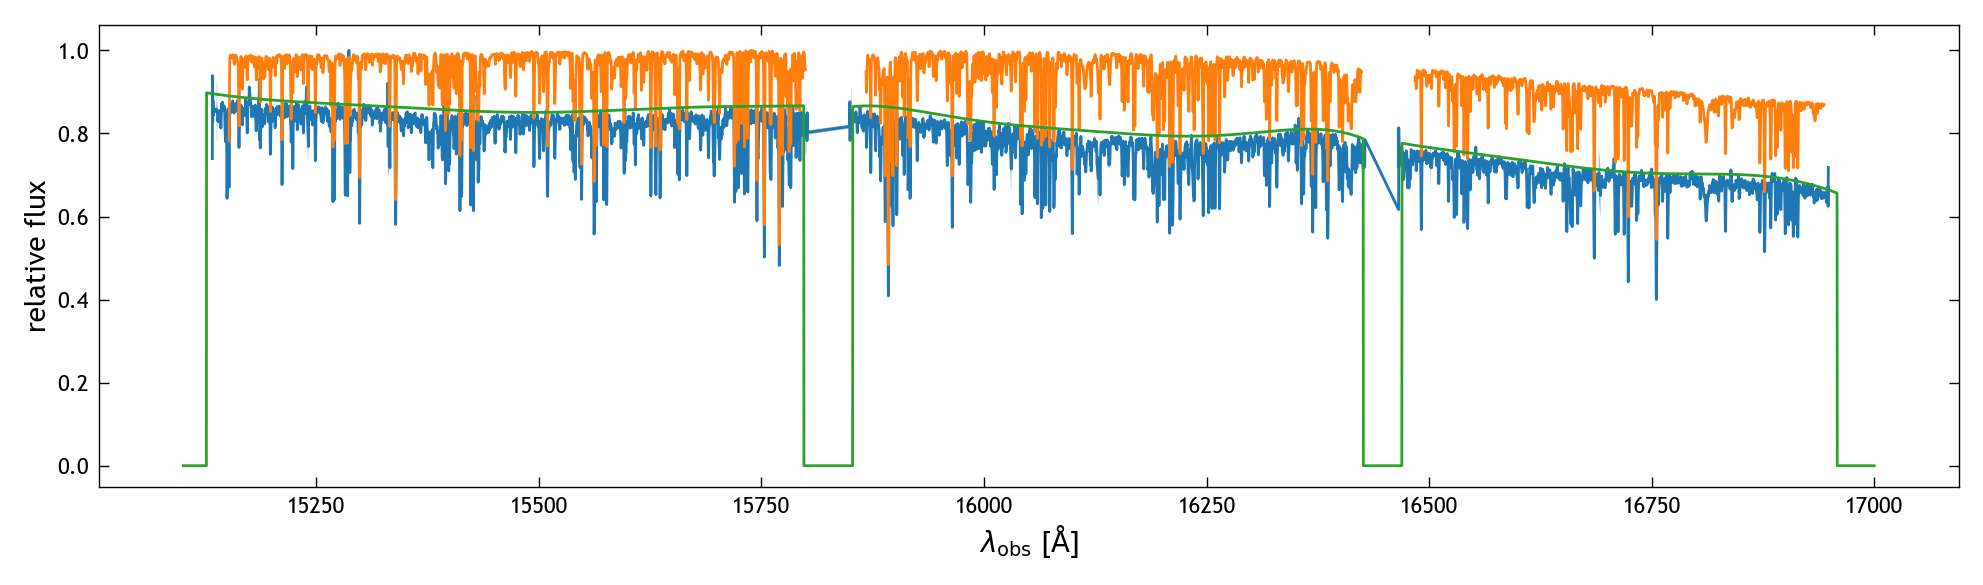

In [37]:
fig, ax = plt.subplots(figsize=(12, 3))
mask = obs_err < 0.1 * obs_flux
maxflux = obs_flux[mask].max()
ax.plot(obs_wl[mask], obs_flux[mask]/maxflux)
ax.fill_between(
    obs_wl[mask], 
    (obs_flux[mask] - obs_err[mask])/maxflux, 
    (obs_flux[mask] + obs_err[mask])/maxflux, 
    alpha=0.5
)
ax.plot(model_wl, model_flux/model_flux.max())
ax.plot(obs_wl, obs_cont/maxflux)
ax.set_xlabel(r'$\lambda_{\rm obs}$ [${\rm \AA}$]')
ax.set_ylabel('relative flux')
plt.show()

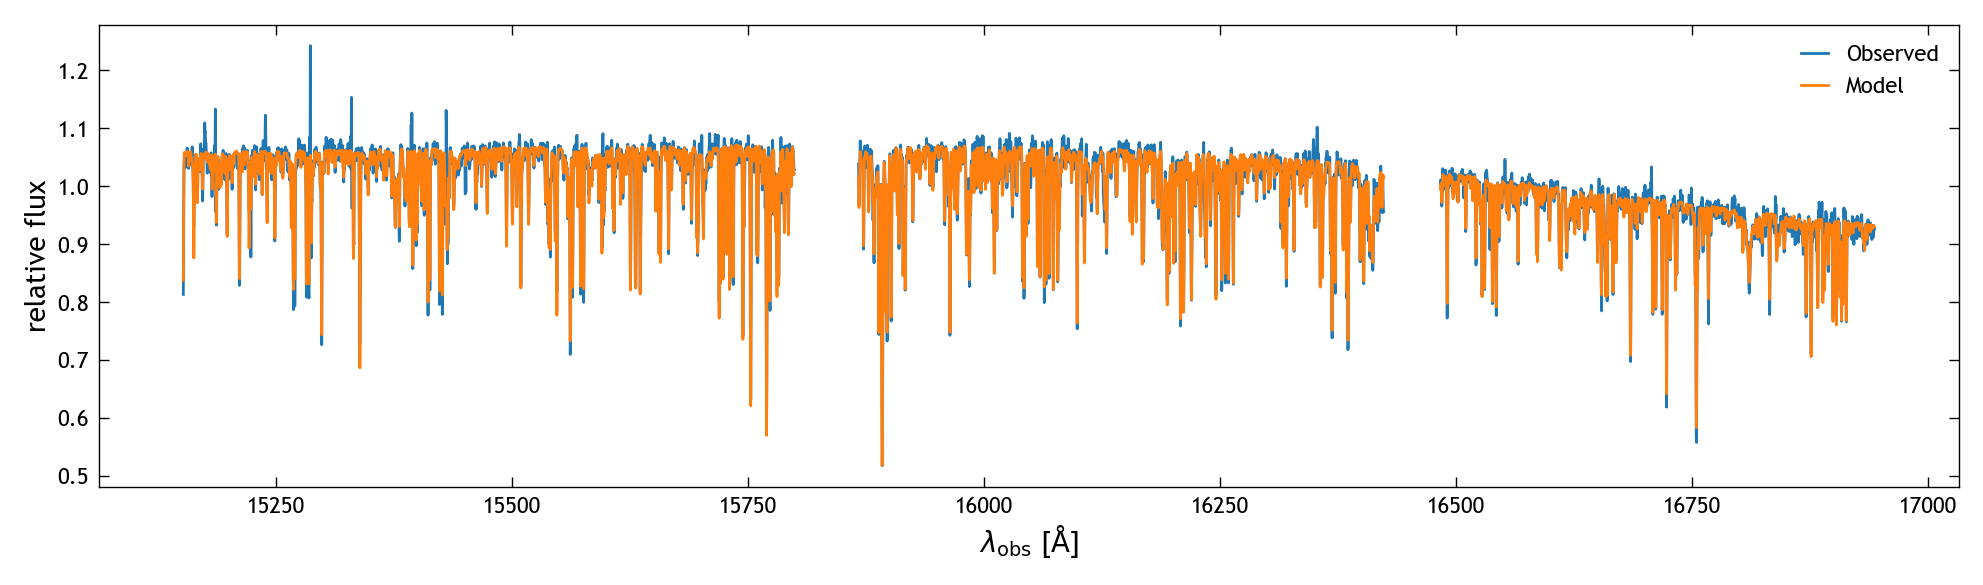

In [38]:
fig, ax = plt.subplots(figsize=(12, 3))
mask = obs_err < 0.1 * obs_flux
maxflux = obs_flux[mask].max()
ax.plot(obs_wl[mask], obs_flux[mask]/model_cont[mask], label='Observed')
ax.plot(model_wl, model_flux, label='Model')
# ax.plot(obs_wl, obs_cont/maxflux)
ax.set_xlabel(r'$\lambda_{\rm obs}$ [${\rm \AA}$]')
ax.set_ylabel('relative flux')
ax.legend()
plt.show()

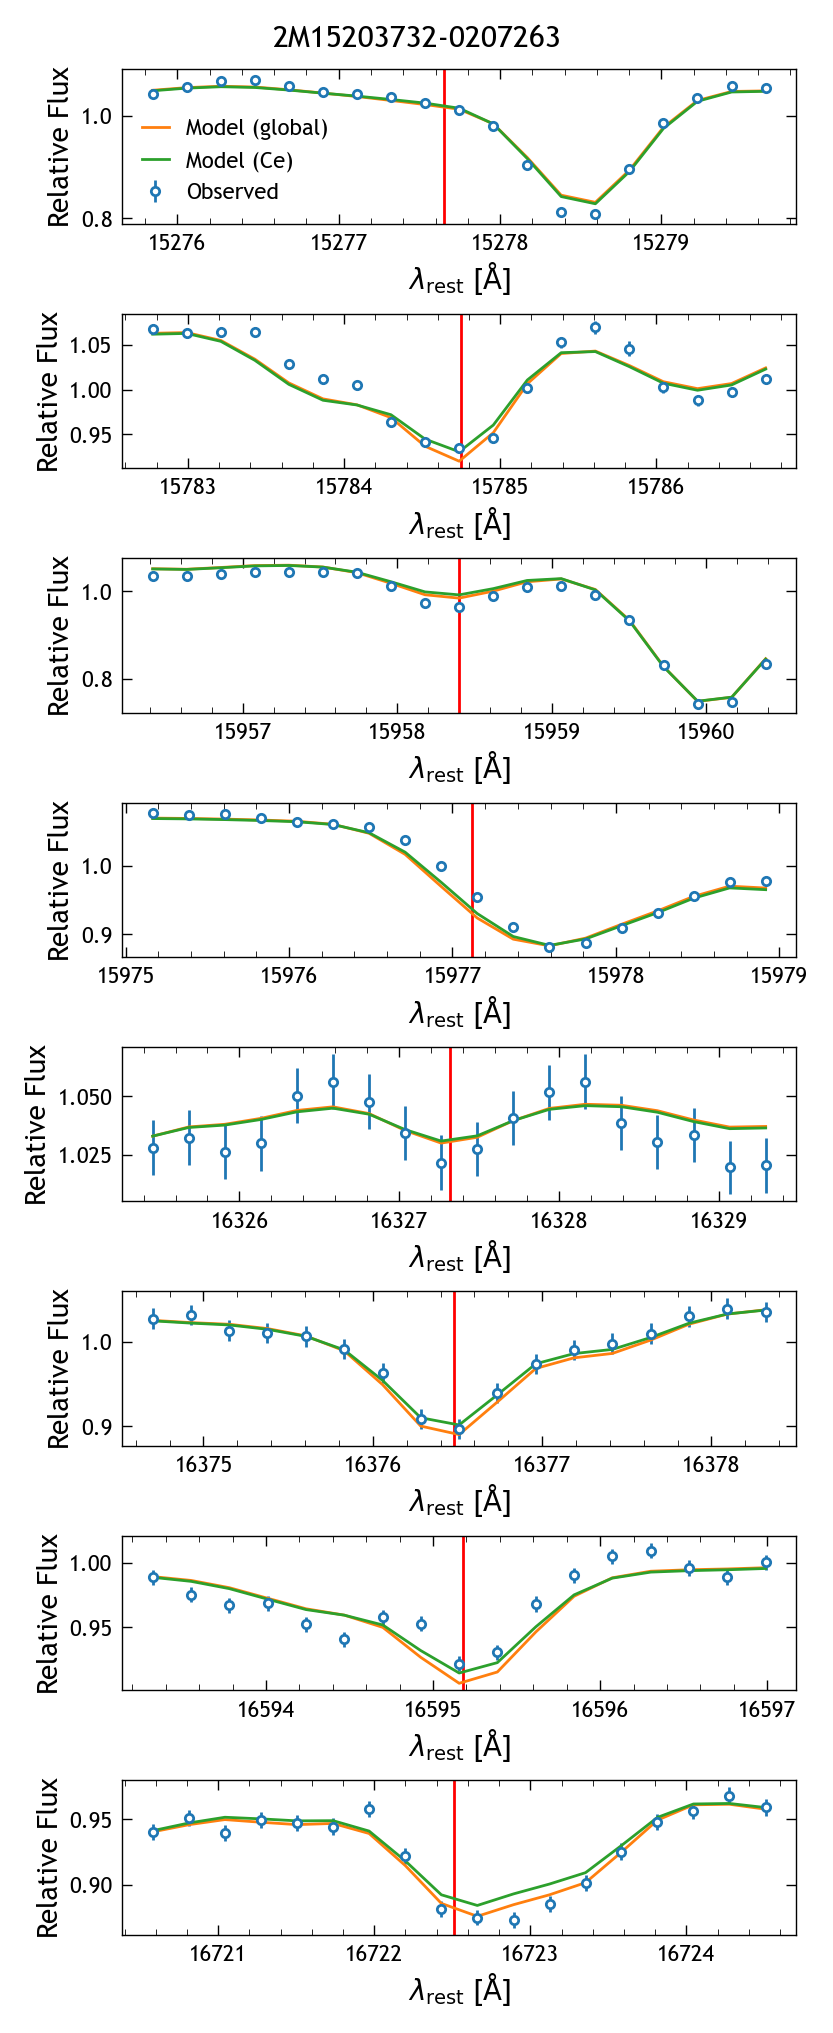

In [ ]:
# Individual lines
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(8, figsize=(4, 10), constrained_layout=True)
for i, ax in enumerate(axs):
    line = ce_ii_lines[i]
    ax.axvline(line, color='r')
    wl_range = (line-2, line+2)
    mask = (air_wl >= wl_range[0]) & (air_wl < wl_range[1])
    ax.errorbar(
        air_wl[mask], obs_flux[mask]/model_cont[mask], 
        yerr=obs_err[mask]/model_cont[mask], 
        fmt='o', ms=3, mfc='w', capsize=0,
        label='Observed'
    )
    ax.plot(air_wl[mask], model_flux[mask], label='Model (global)')
    ax.plot(air_wl[mask], model_ce_flux[mask], label='Model (Ce)')
    ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
    ax.set_ylabel('Relative Flux')
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[0].legend()
fig.suptitle(mwmStar['obj'][0])
plt.show()

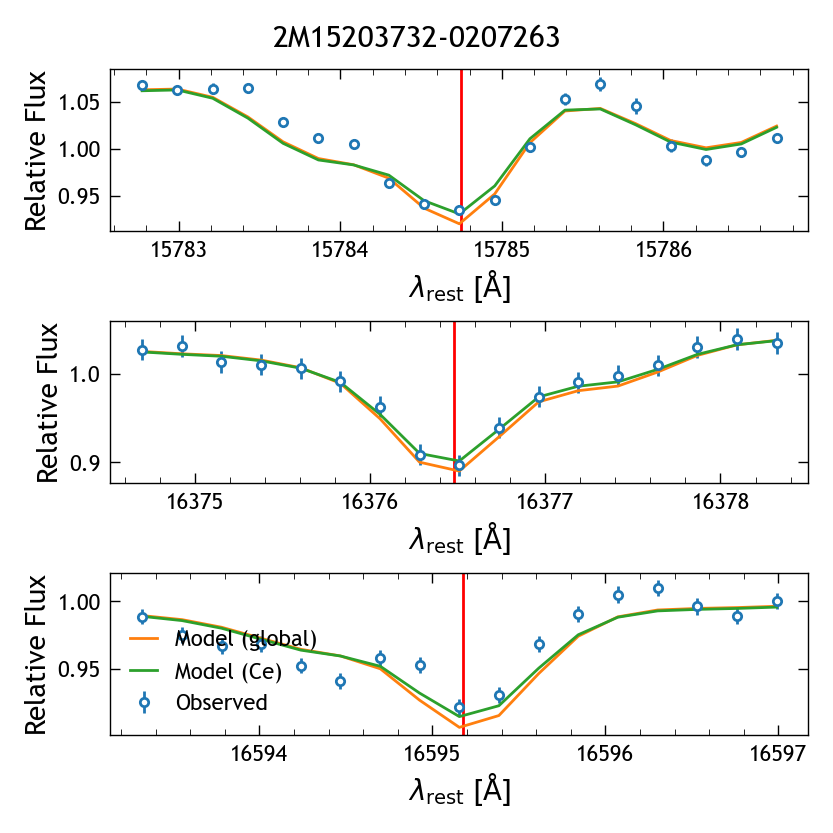

In [42]:
# Individual lines
# Comparison with Cunha+ (2017) Figure 6, for 2M15203732-0207263
ce_ii_lines = [15784.75, 16376.48, 16595.18] # Angstroms

fig, axs = plt.subplots(3, figsize=(4, 4), constrained_layout=True)
for i, ax in enumerate(axs):
    line = ce_ii_lines[i]
    ax.axvline(line, color='r')
    # ax.axvline(line+3.8, color='r', linestyle='--')
    wl_range = (line-2, line+2)
    mask = (air_wl >= wl_range[0]) & (air_wl < wl_range[1])
    ax.errorbar(
        air_wl[mask], obs_flux[mask]/model_cont[mask], 
        yerr=obs_err[mask]/model_cont[mask], 
        fmt='o', ms=3, mfc='w', capsize=0,
        label='Observed'
    )
    ax.plot(air_wl[mask], model_flux[mask], label='Model (global)')
    ax.plot(air_wl[mask], model_ce_flux[mask], label='Model (Ce)')
    ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
    ax.set_ylabel('Relative Flux')
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[-1].legend(loc='lower left')
fig.suptitle(mwmStar['obj'][0])
plt.show()

## Comparing spectra with similar Ce, Fe at different log(g)

In [144]:
solar_abund = mwm_sample[
    (mwm_sample['fe_h'] >= -0.02) &
    (mwm_sample['fe_h'] < 0.02) &
    (mwm_sample['mg_h'] >= -0.02) &
    (mwm_sample['mg_h'] < 0.02) &
    (mwm_sample['ce_h'] >= -0.05) &
    (mwm_sample['ce_h'] < 0.05)
]
solar_abund.sort_values('snr', inplace=True)
solar_abund

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
96530885,2M08321534-4842532,5323215971715941248,5323215971715941248,90299181,172344,gaia_dr3_source,31,63050395874484211,5808128675,27021599363941179,...,12.513757,0.0,-0.002643,0.023559,0.004665,-0.004665,0.030867,0.026202,True,False
62864131,NaN,1721949627026844160,1721949627026844160,335661668,1067,tic_v8,25,27021597907297195,4348252985,27021597907297195,...,9.450279,0.0,0.004826,0.071906,-0.008928,0.008928,0.058152,0.067080,True,False
103019162,2M12261245-6653360,5860037921130857984,5860037921130857984,325384203,188674,gaia_dr3_source,31,63050396092842734,5696458384,27021599252448042,...,8.173843,0.0,0.009276,0.039665,-0.007728,0.007728,0.022661,0.030389,True,False
65869921,2M23525637+6108289,2011921152868663168,2011921152868663168,378291931,12322,gaia_dr3_source,31,63050394949130395,4256684386,27021597816117750,...,13.510449,0.0,-0.007880,0.052653,0.003843,-0.003843,0.064376,0.060533,True,False
97155115,2M10292030-5011542,5358086364516635648,5358086364516635648,447522458,174109,gaia_dr3_source,31,63050395911935971,5743797310,27021599299701040,...,9.948754,0.0,0.006478,0.001599,0.023494,-0.023494,0.018615,-0.004879,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60187820,2M15163489+3152275,1277927391046964736,1277927391046964736,16272966,46662,gaia_dr3_source,31,63050394842323247,5188404207,27021599488641295,...,7.865635,0.0,0.015159,0.016045,0.023032,-0.023032,0.023917,0.000886,True,False
72644900,2M06474120-2259501,2925354800009122560,2925354800009122560,49387723,136593,gaia_dr3_source,31,63050395081718012,4453469328,27021599489647524,...,6.985213,0.0,0.009603,0.053981,0.010416,-0.010416,0.054794,0.044378,True,False
56442772,NaN,680524584366680576,680524584366680576,367566901,58284,tic_v8,21,4554312032,4554312032,27021599488482588,...,8.560064,0.0,0.015331,0.101682,0.014867,-0.014867,0.101218,0.086351,True,False


In [145]:
solar_abund_high_snr_ids = []
solar_abund_low_snr_ids = []
logg_bins = [1, 1.5, 2, 2.5, 3, 3.5]
for i in range(len(logg_bins)-1):
    solar_abund_logg = solar_abund[
        (solar_abund['logg'] >= logg_bins[i]) &
        (solar_abund['logg'] < logg_bins[i+1])
    ]
    solar_abund_low_snr_ids.append(solar_abund_logg.index[0])
    solar_abund_high_snr_ids.append(solar_abund_logg.index[-1])

print(solar_abund_low_snr_ids)
print(solar_abund_high_snr_ids)

[np.int64(96951923), np.int64(103019162), np.int64(96530885), np.int64(62864131), np.int64(85166796)]
[np.int64(96951923), np.int64(56306785), np.int64(72644900), np.int64(62466542), np.int64(91786587)]


In [146]:
mwm_sample.loc[solar_abund_high_snr_ids].telescope

sdss_id
96951923    lco25m
56306785    apo25m
72644900    lco25m
62466542    apo25m
91786587    lco25m
Name: telescope, dtype: str

In [147]:
# Download data
access.remote()
for sdss_id in solar_abund_high_snr_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:  40%|████      | 8/20 [00:05<00:07,  1.60files/s, n_files=20, n_streams=5]

SDSS_ACCESS> Done!


In [148]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in solar_abund_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_66092/3334600947.py:12: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



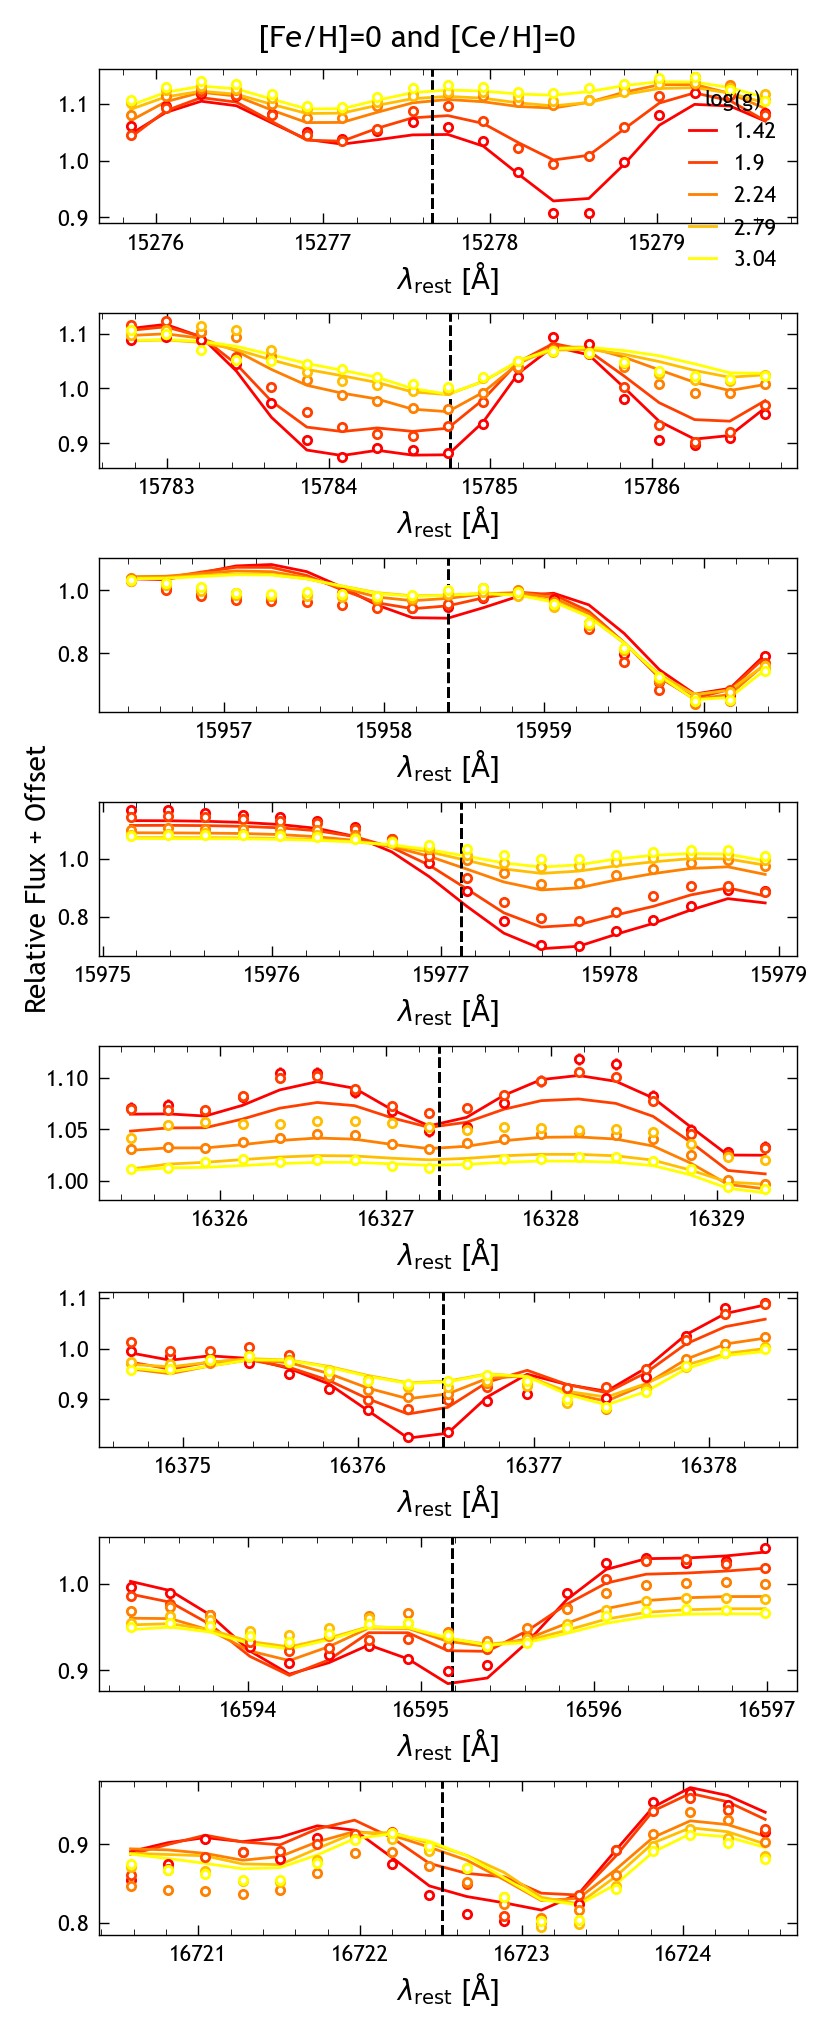

In [149]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(8, figsize=(4, 10), constrained_layout=True)
offsets = [-0.2, -0.1, 0, 0.1, 0.2]
cmap = plt.get_cmap('autumn')
norm = BoundaryNorm(logg_bins, cmap.N)
for j, sdss_id in enumerate(solar_abund_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    model = aspcap['model_flux_ce_h'][0]
    logg = mwm_sample.loc[sdss_id]['logg']
    for i, ax in enumerate(axs):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        # ax.plot(wl_arr[mask], flux[mask]/flux[mask].max(), label=round(logg, 2))
        # ax.fill_between(
        #     wl_arr[mask],
        #     (flux[mask] - flux_err[mask]) / flux[mask].max(),
        #     (flux[mask] + flux_err[mask]) / flux[mask].max(),
        #     alpha=0.5
        # )
        ax.errorbar(
            wl_arr[mask], flux[mask], 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(logg))
            # label=round(logg, 2)
        )
        ax.plot(wl_arr[mask], model[mask], c=cmap(norm(logg)), label=round(logg, 2))
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    axs[0].legend(title='log(g)')
axs[3].set_ylabel('Relative Flux + Offset')
fig.suptitle('[Fe/H]=0 and [Ce/H]=0')
plt.show()

## Same log(g) and [Fe/H], different [Ce/H]

### Upper RGB

In [127]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.52) &
    (mwm_sample['fe_h'] < 0.48) &
    (mwm_sample['mg_fe'] >= -0.05) &
    (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['logg'] >= 1.9) &
    (mwm_sample['logg'] < 2.1)
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
54932508,NaN,469856850823497088,469856850823497088,86645338,15368,tic_v8,25,27021597891489478,4332352365,27021597891489478,...,12.607650,0.0,-0.323009,0.076498,0.002710,-0.002710,0.402217,0.399506,True,False
76470989,NaN,3326518317546202240,3326518317546202240,231148475,82830,tic_v8,25,27021598085979283,4528326595,27021598085979283,...,14.145262,0.0,-0.245254,0.187490,-0.009568,0.009568,0.423176,0.432744,True,False
65874955,NaN,2012313403637031808,2012313403637031808,270547910,12953,tic_v8,25,27021597814808615,4255372540,27021597814808615,...,9.735571,0.0,-0.207352,0.281541,0.047925,-0.047925,0.536818,0.488893,True,False
87439485,NaN,4280098260981031680,4280098260981031680,107908584,92814,tic_v8,25,27021598756836432,5200406841,27021598756836432,...,5.867080,0.0,0.062581,0.120462,0.030815,-0.030815,0.088696,0.057881,True,False
107136613,2M12191400-6235432,6054437349347365888,6054437349347365888,309989513,185659,gaia_dr3_source,31,63050396399387537,5502183411,27021599058274979,...,8.312120,0.0,0.097452,0.243261,0.036128,-0.036128,0.181937,0.145809,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57450771,2M07390891+2203222,865454292604141824,865454292604141824,70462448,61347,gaia_dr3_source,31,63050394824636985,4543229857,27021599488352760,...,10.956695,0.0,-0.215212,0.102979,0.003841,-0.003841,0.322031,0.318190,True,False
57580792,2M07434852+3004334,879153279773538048,879153279773538048,4299486,48549,gaia_dr3_source,31,63050394825506851,4551562095,27021599488618872,...,9.079046,0.0,-0.150202,0.144700,0.021212,-0.021212,0.316114,0.294902,True,False
55758412,NaN,576462057973762944,576462057973762944,858755,97728,tic_v8,25,27021599488103584,4545172695,27021599488103584,...,10.313531,0.0,-0.393588,0.217625,-0.044915,0.044915,0.566297,0.611213,True,False


In [114]:
same_logg_feh['ce_fe'].max()

np.float64(1.3401512)

In [116]:
same_logg_high_snr_ids = []
cefe_bins = np.arange(-0.5, 0.51, 0.2)
for i in range(len(cefe_bins)-1):
    same_logg_cefe = same_logg_feh[
        (same_logg_feh['ce_fe'] >= cefe_bins[i]) &
        (same_logg_feh['ce_fe'] < cefe_bins[i+1])
    ]
    same_logg_high_snr_ids.append(same_logg_cefe.index[-1])

print(same_logg_high_snr_ids)

[np.int64(75933928), np.int64(114508969), np.int64(129059737), np.int64(129058716), np.int64(129060146)]


In [121]:
# Download data
access.reset()
access.remote()
for sdss_id in same_logg_high_snr_ids:
    print(sdss_id)
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

75933928
114508969
129059737
129058716
129060146


Progress:  60%|██████    | 6/10 [00:05<00:03,  1.20files/s, n_files=10, n_streams=5]

SDSS_ACCESS> Done!


In [122]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in same_logg_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_66092/1611263725.py:11: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



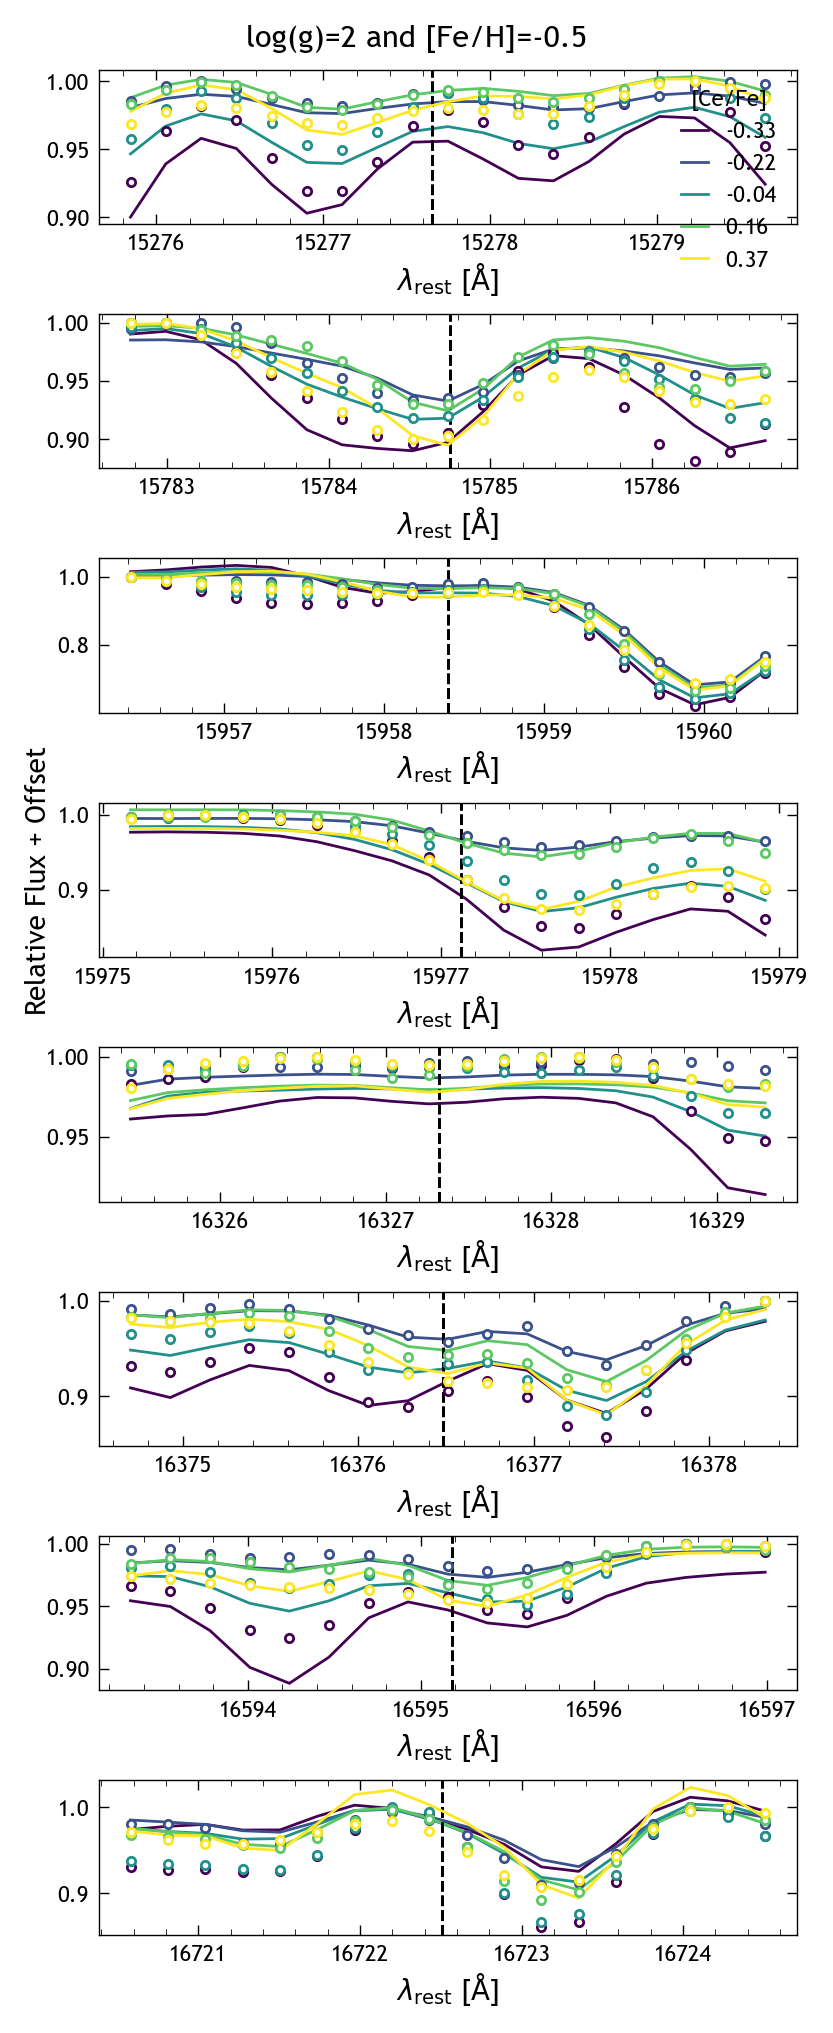

In [142]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(8, figsize=(4, 10), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(cefe_bins, cmap.N)
for j, sdss_id in enumerate(same_logg_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    model = aspcap['model_flux_ce_h'][0]
    cefe = mwm_sample.loc[sdss_id]['ce_fe']
    for i, ax in enumerate(axs):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        ax.errorbar(
            wl_arr[mask], flux[mask]/flux[mask].max(), 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(cefe))
        )
        ax.plot(
            wl_arr[mask], model[mask]/flux[mask].max(), 
            c=cmap(norm(cefe)), 
            label=round(cefe, 2)
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    axs[0].legend(title='[Ce/Fe]')
axs[3].set_ylabel('Relative Flux + Offset')
fig.suptitle('log(g)=2 and [Fe/H]=-0.5')
plt.show()

### Lower RGB

In [128]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.52) &
    (mwm_sample['fe_h'] < 0.48) &
    (mwm_sample['mg_fe'] >= -0.05) &
    (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1)
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
67948216,NaN,2156045514983120384,2156045514983120384,233628181,12258,tic_v8,25,27021597828084150,4268699410,27021597828084150,...,9.955434,0.0,-0.129665,-0.025377,-0.026955,0.026955,0.077333,0.104288,True,False
69244655,NaN,2304126297902453248,2304126297902453248,398371830,175,tic_v8,25,27021599489248901,4286837212,27021599489248901,...,9.770714,0.0,-0.009777,0.379304,0.048229,-0.048229,0.437311,0.389081,True,False
109059259,2M16013774-2056415,6243673711452189568,6243673711452189568,9669128,133718,gaia_dr3_source,31,63050396458092928,4774187407,27021598331024406,...,6.446855,0.0,0.199429,-0.234699,0.046420,-0.046420,-0.387709,-0.434129,True,False
108980640,2M15563776-2604458,6235369576859830912,6235369576859830912,77534933,141908,gaia_dr3_source,31,63050396456577647,4616685555,27021598173572079,...,6.382520,0.0,0.355558,0.562421,-0.003287,0.003287,0.203576,0.206862,True,False
97921869,2M09191749-4105317,5427868965911516416,5427868965911516416,3844740,162758,gaia_dr3_source,31,63050395933617207,5794900801,27021599350738412,...,9.326145,0.0,-0.026492,0.127402,-0.007227,0.007227,0.146667,0.153894,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62894142,2M15211596+8724171,1728830478168686976,1728830478168686976,160115783,101,gaia_dr3_source,31,63050394855453938,4348127117,27021599489246010,...,9.063726,0.0,0.027088,0.124794,0.058758,-0.058758,0.156464,0.097706,True,False
71983283,NaN,2854069372364214400,2854069372364214400,238431679,51970,tic_v8,21,4402830685,4402830685,27021599488442143,...,8.774186,0.0,-0.245534,-0.181514,-0.003363,0.003363,0.060658,0.064021,True,False
56424349,NaN,677685885862404736,677685885862404736,82326857,58800,tic_v8,21,4554466830,4554466830,27021599488482768,...,8.150458,0.0,-0.216812,0.063456,-0.004359,0.004359,0.275908,0.280268,True,False


In [136]:
same_logg_high_snr_ids = []
cefe_bins = np.arange(-0.5, 0.51, 0.2)
for i in range(len(cefe_bins)-1):
    same_logg_cefe = same_logg_feh[
        (same_logg_feh['ce_fe'] >= cefe_bins[i]) &
        (same_logg_feh['ce_fe'] < cefe_bins[i+1])
    ]
    same_logg_high_snr_ids.append(same_logg_cefe.index[-1])

print(same_logg_high_snr_ids)

[np.int64(70840851), np.int64(80034976), np.int64(62889663), np.int64(56424349), np.int64(57009006)]


In [137]:
# Download data
access.reset()
access.remote()
for sdss_id in same_logg_high_snr_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:   0%|          | 0/10 [00:00<?, ?files/s, n_files=10, n_streams=5]

SDSS_ACCESS> Done!


In [138]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in same_logg_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_66092/1477782172.py:11: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



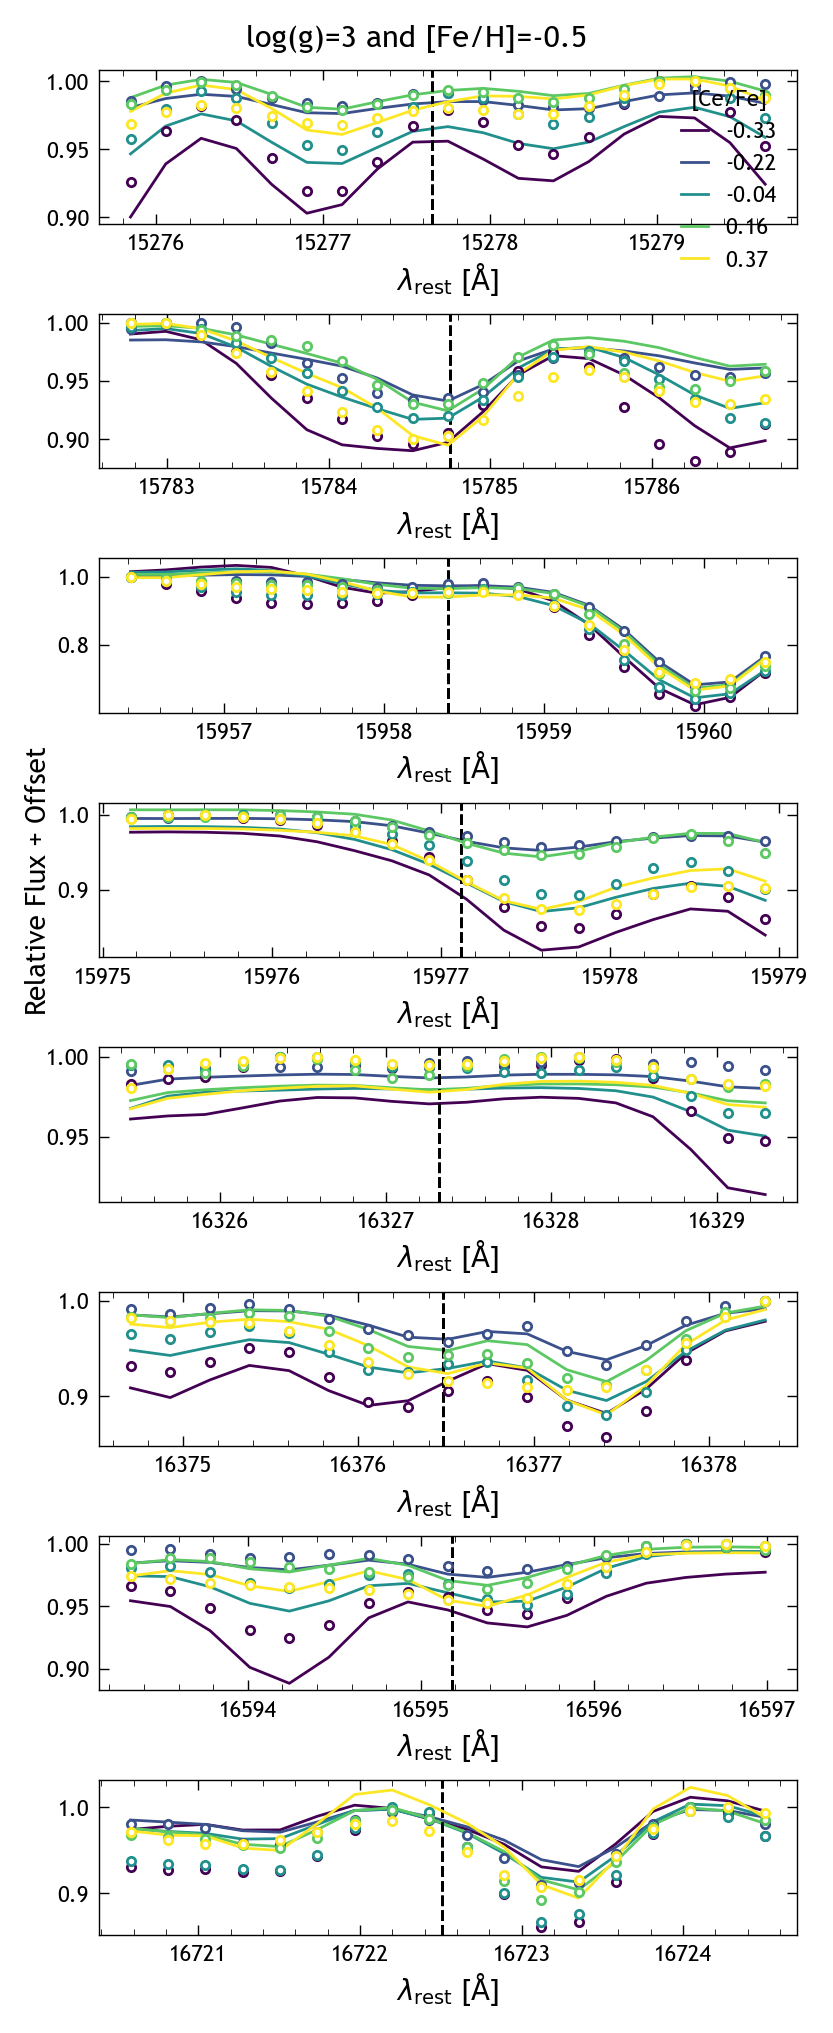

In [141]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(8, figsize=(4, 10), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(cefe_bins, cmap.N)
for j, sdss_id in enumerate(same_logg_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    model = aspcap['model_flux_ce_h'][0]
    cefe = mwm_sample.loc[sdss_id]['ce_fe']
    for i, ax in enumerate(axs):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        ax.errorbar(
            wl_arr[mask], flux[mask]/flux[mask].max(), 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(cefe))
        )
        ax.plot(
            wl_arr[mask], model[mask]/flux[mask].max(), 
            c=cmap(norm(cefe)), 
            label=round(cefe, 2)
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    axs[0].legend(title='[Ce/Fe]')
axs[3].set_ylabel('Relative Flux + Offset')
fig.suptitle('log(g)=3 and [Fe/H]=-0.5')
plt.show()

### Metal-rich

In [ ]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.52) &
    (mwm_sample['fe_h'] < 0.48) &
    (mwm_sample['mg_fe'] >= -0.05) &
    (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1)
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh